# Modelo de clasificación de celdas del Sudoku

Nueva versión del clasificador:

```text
0 = celda vacía
1–9 = números impresos
```

El modelo anterior se entrenaba únicamente con MNIST manuscrito.

Esta versión genera celdas sintéticas similares a las del Sudoku:

- números impresos;
- diferentes tipografías;
- variaciones de posición y tamaño;
- ruido;
- desenfoque;
- pequeñas rotaciones;
- restos de líneas de la cuadrícula;
- celdas vacías.

Después se entrena una CNN pequeña.

## 1. Conectar Google Drive

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 2. Importar librerías

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow:", tf.__version__)
print("GPU disponible:", len(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
GPU disponible: 1


## 3. Configuración

In [ ]:
MUESTRAS_POR_CLASE = 5000
EPOCHS = 15
BATCH_SIZE = 64

# Cambiar a False después de guardar el modelo
ENTRENAR_MODELO = False

np.random.seed(42)

## 4. Preprocesamiento de una celda

La celda original tiene aproximadamente `50 × 50` píxeles.

El preprocesamiento:

1. elimina el margen exterior;
2. convierte la imagen a blanco y negro;
3. busca el componente principal;
4. recorta el número;
5. conserva su proporción;
6. lo centra en una imagen de `28 × 28`.

Si no existe contenido suficiente, devuelve una imagen vacía.

In [4]:
def preparar_celda(celda, margen=5, area_minima=20):

    if len(celda.shape) == 3:
        celda = cv2.cvtColor(
            celda,
            cv2.COLOR_BGR2GRAY
        )

    celda = celda[
        margen:-margen,
        margen:-margen
    ]

    celda = cv2.GaussianBlur(
        celda,
        (3, 3),
        0
    )

    _, binaria = cv2.threshold(
        celda,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    contornos, _ = cv2.findContours(
        binaria,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contornos) == 0:
        return np.zeros((28, 28), dtype=np.uint8)

    contorno = max(
        contornos,
        key=cv2.contourArea
    )

    if cv2.contourArea(contorno) < area_minima:
        return np.zeros((28, 28), dtype=np.uint8)

    x, y, ancho, alto = cv2.boundingRect(contorno)

    contenido = binaria[
        y:y + alto,
        x:x + ancho
    ]

    escala = 20 / max(ancho, alto)

    nuevo_ancho = max(
        1,
        int(ancho * escala)
    )

    nuevo_alto = max(
        1,
        int(alto * escala)
    )

    contenido = cv2.resize(
        contenido,
        (nuevo_ancho, nuevo_alto),
        interpolation=cv2.INTER_AREA
    )

    imagen = np.zeros(
        (28, 28),
        dtype=np.uint8
    )

    inicio_x = (28 - nuevo_ancho) // 2
    inicio_y = (28 - nuevo_alto) // 2

    imagen[
        inicio_y:inicio_y + nuevo_alto,
        inicio_x:inicio_x + nuevo_ancho
    ] = contenido

    momentos = cv2.moments(imagen)

    if momentos["m00"] != 0:

        centro_x = momentos["m10"] / momentos["m00"]
        centro_y = momentos["m01"] / momentos["m00"]

        mover_x = int(round(14 - centro_x))
        mover_y = int(round(14 - centro_y))

        matriz = np.float32([
            [1, 0, mover_x],
            [0, 1, mover_y]
        ])

        imagen = cv2.warpAffine(
            imagen,
            matriz,
            (28, 28)
        )

    return imagen

## 5. Generar celdas sintéticas

Utilizamos varias tipografías de OpenCV y alteramos ligeramente cada celda.

Las imágenes se generan primero a `50 × 50` y después pasan por el mismo preprocesamiento que utilizará la aplicación.

In [5]:
FUENTES = [
    cv2.FONT_HERSHEY_SIMPLEX,
    cv2.FONT_HERSHEY_DUPLEX,
    cv2.FONT_HERSHEY_COMPLEX,
    cv2.FONT_HERSHEY_TRIPLEX,
    cv2.FONT_HERSHEY_COMPLEX_SMALL
]


def crear_celda_sintetica(numero):

    fondo = np.random.randint(
        225,
        256
    )

    celda = np.full(
        (50, 50),
        fondo,
        dtype=np.uint8
    )

    if np.random.random() < 0.7:

        color_linea = np.random.randint(
            130,
            230
        )

        grosor_linea = np.random.randint(
            1,
            3
        )

        lado = np.random.randint(
            0,
            4
        )

        if lado == 0:
            cv2.line(
                celda,
                (0, 1),
                (49, 1),
                color_linea,
                grosor_linea
            )

        elif lado == 1:
            cv2.line(
                celda,
                (48, 0),
                (48, 49),
                color_linea,
                grosor_linea
            )

        elif lado == 2:
            cv2.line(
                celda,
                (0, 48),
                (49, 48),
                color_linea,
                grosor_linea
            )

        else:
            cv2.line(
                celda,
                (1, 0),
                (1, 49),
                color_linea,
                grosor_linea
            )

    if numero != 0:

        fuente = FUENTES[
            np.random.randint(
                0,
                len(FUENTES)
            )
        ]

        escala = np.random.uniform(
            0.85,
            1.25
        )

        grosor = np.random.randint(
            1,
            4
        )

        color = np.random.randint(
            0,
            90
        )

        texto = str(numero)

        (ancho, alto), _ = cv2.getTextSize(
            texto,
            fuente,
            escala,
            grosor
        )

        posicion_x = (
            25
            - ancho // 2
            + np.random.randint(-3, 4)
        )

        posicion_y = (
            25
            + alto // 2
            + np.random.randint(-3, 4)
        )

        cv2.putText(
            celda,
            texto,
            (posicion_x, posicion_y),
            fuente,
            escala,
            color,
            grosor,
            cv2.LINE_AA
        )

    angulo = np.random.uniform(
        -5,
        5
    )

    matriz = cv2.getRotationMatrix2D(
        (25, 25),
        angulo,
        1
    )

    celda = cv2.warpAffine(
        celda,
        matriz,
        (50, 50),
        borderValue=int(fondo)
    )

    if np.random.random() < 0.3:

        celda = cv2.GaussianBlur(
            celda,
            (3, 3),
            0
        )

    ruido = np.random.normal(
        0,
        np.random.uniform(1, 6),
        celda.shape
    )

    celda = np.clip(
        celda.astype("float32") + ruido,
        0,
        255
    ).astype("uint8")

    return celda

In [6]:
def crear_dataset(muestras_por_clase):

    total = muestras_por_clase * 10

    X = np.zeros(
        (total, 28, 28),
        dtype=np.uint8
    )

    y = np.zeros(
        total,
        dtype=np.uint8
    )

    posicion = 0

    for numero in range(10):

        for _ in range(muestras_por_clase):

            celda = crear_celda_sintetica(
                numero
            )

            X[posicion] = preparar_celda(
                celda
            )

            y[posicion] = numero
            posicion += 1

    indices = np.random.permutation(
        total
    )

    return X[indices], y[indices]


X, y = crear_dataset(
    MUESTRAS_POR_CLASE
)

print("X:", X.shape)
print("y:", y.shape)
print("Clases:", np.unique(y))

X: (50000, 28, 28)
y: (50000,)
Clases: [0 1 2 3 4 5 6 7 8 9]


## 6. Visualizar ejemplos

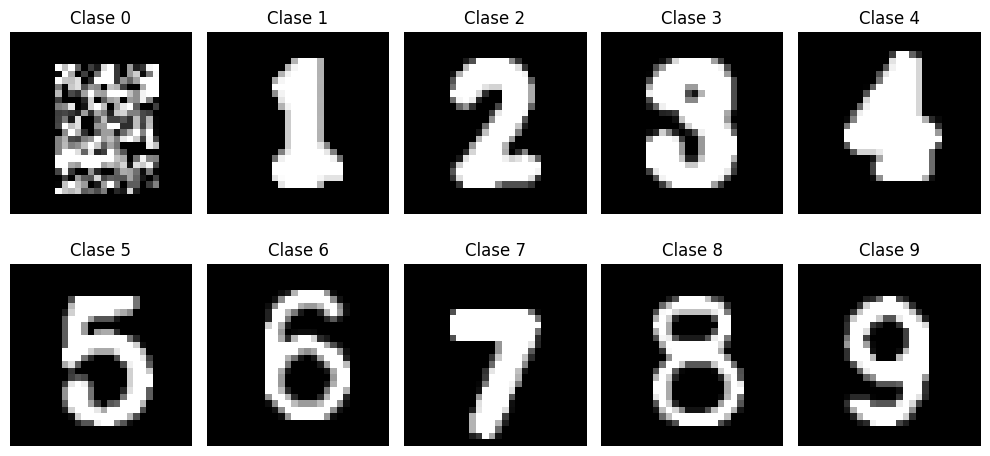

In [7]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(10, 5)
)

for numero, ax in enumerate(axes.flat):

    indice = np.where(
        y == numero
    )[0][0]

    ax.imshow(
        X[indice],
        cmap="gray"
    )

    ax.set_title(
        f"Clase {numero}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Separar train y test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = (
    X_train.astype("float32")
    / 255.0
)

X_test = (
    X_test.astype("float32")
    / 255.0
)

X_train = X_train.reshape(
    -1,
    28,
    28,
    1
)

X_test = X_test.reshape(
    -1,
    28,
    28,
    1
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (40000, 28, 28, 1)
Test: (10000, 28, 28, 1)


## 8. Crear la CNN

Se utiliza una arquitectura pequeña y compacta, siguiendo el estilo visto en clase.

In [9]:
modelo_class = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.RandomRotation(0.04),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomZoom(0.08),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

modelo_class.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_class.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Entrenar el modelo

In [10]:
if ENTRENAR_MODELO:

    checkpoint = keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/proyecto_DL/modelo_class/modelo/best_class_0_9.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    )

    history = modelo_class.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        callbacks=[
            checkpoint,
            early_stopping
        ],
        verbose=1
    )

else:

    print(
        "Entrenamiento desactivado. "
        "Cambia ENTRENAR_MODELO a True para ejecutarlo."
    )

Epoch 1/15
497/500 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7717 - loss: 0.7097
Epoch 1: val_accuracy improved from None to 0.99687, saving model to /content/drive/MyDrive/proyecto_DL/modelo_class/modelo/best_class_0_9.keras

Epoch 1: finished saving model to /content/drive/MyDrive/proyecto_DL/modelo_class/modelo/best_class_0_9.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9008 - loss: 0.3078 - val_accuracy: 0.9969 - val_loss: 0.0180
Epoch 2/15
494/500 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9739 - loss: 0.0765
Epoch 2: val_accuracy improved from 0.99687 to 0.99850, saving model to /content/drive/MyDrive/proyecto_DL/modelo_class/modelo/best_class_0_9.keras

Epoch 2: finished saving model to /content/drive/MyDrive/proyecto_DL/modelo_class/modelo/best_class_0_9.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9783 - loss: 0.0644 - val_accuracy: 0.9985 - val_loss: 0.0091
Epoch 3/15
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9855 - lo

## 10. Evaluar el modelo

In [11]:
modelo_class = keras.models.load_model(
    "/content/drive/MyDrive/proyecto_DL/modelo_class/modelo/best_class_0_9.keras"
)

loss, accuracy = modelo_class.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Loss:", round(loss, 4))
print("Accuracy:", f"{accuracy:.2%}")

Loss: 0.0035
Accuracy: 99.92%


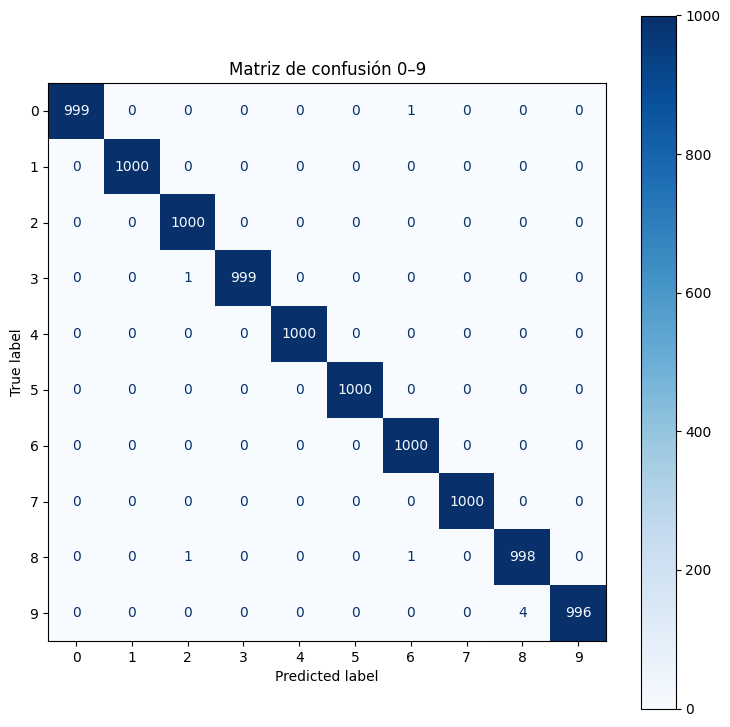

In [12]:
probabilidades = modelo_class.predict(
    X_test,
    verbose=0
)

predicciones = np.argmax(
    probabilidades,
    axis=1
)

matriz = confusion_matrix(
    y_test,
    predicciones
)

fig, ax = plt.subplots(
    figsize=(9, 9)
)

ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=range(10)
).plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión 0–9")
plt.show()

In [13]:
for numero in range(10):

    mascara = y_test == numero

    accuracy_numero = np.mean(
        predicciones[mascara]
        == y_test[mascara]
    )

    print(
        f"Clase {numero}: "
        f"{accuracy_numero:.2%}"
    )

Clase 0: 99.90%
Clase 1: 100.00%
Clase 2: 100.00%
Clase 3: 99.90%
Clase 4: 100.00%
Clase 5: 100.00%
Clase 6: 100.00%
Clase 7: 100.00%
Clase 8: 99.80%
Clase 9: 99.60%


## 11. Predecir una celda

La aplicación enviará una celda de aproximadamente `50 × 50`.

La función devuelve directamente:

```text
0 = vacía
1–9 = número
```

In [14]:
def predecir_celda(celda, modelo):

    celda_modelo = preparar_celda(
        celda
    )

    entrada = (
        celda_modelo.astype("float32")
        / 255.0
    ).reshape(
        1,
        28,
        28,
        1
    )

    probabilidades = modelo.predict(
        entrada,
        verbose=0
    )[0]

    numero = np.argmax(
        probabilidades
    )

    confianza = probabilidades[
        numero
    ]

    return int(numero), float(confianza)

## 12. Probar varias celdas sintéticas

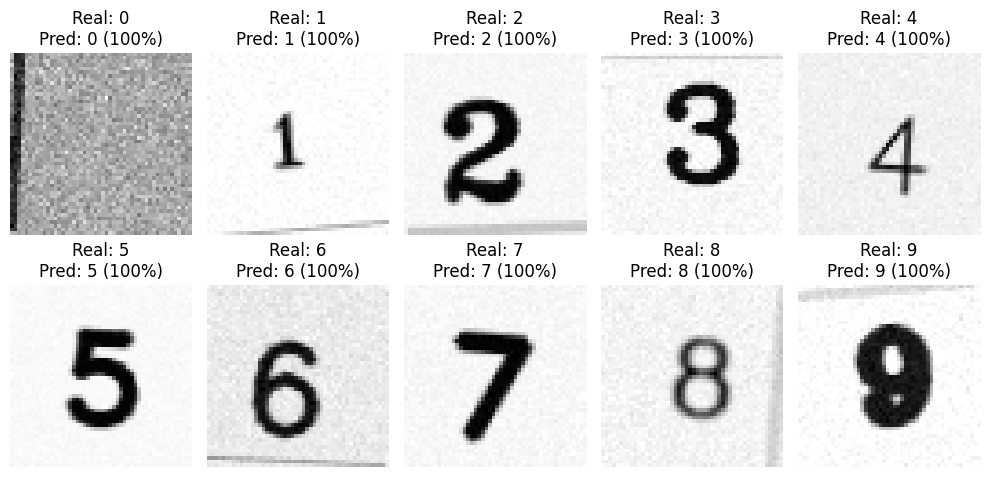

In [15]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(10, 5)
)

for numero_real, ax in enumerate(axes.flat):

    celda = crear_celda_sintetica(
        numero_real
    )

    numero_predicho, confianza = predecir_celda(
        celda,
        modelo_class
    )

    ax.imshow(
        celda,
        cmap="gray"
    )

    ax.set_title(
        f"Real: {numero_real}\n"
        f"Pred: {numero_predicho} "
        f"({confianza:.0%})"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()